# Point cloud classification with PointNet

**Author:** [David Griffiths](https://dgriffiths3.github.io)<br>
**Date created:** 2020/05/25<br>
**Last modified:** 2024/01/09<br>
**Description:** Implementation of PointNet for ModelNet10 classification.

# Point cloud classification

## Introduction

Classification, detection and segmentation of unordered 3D point sets i.e. point clouds
is a core problem in computer vision. This example implements the seminal point cloud
deep learning paper [PointNet (Qi et al., 2017)](https://arxiv.org/abs/1612.00593). For a
detailed intoduction on PointNet see [this blog
post](https://medium.com/@luis_gonzales/an-in-depth-look-at-pointnet-111d7efdaa1a).

## Setup

If using colab first install trimesh with `!pip install trimesh`.

In [1]:
!pip install trimesh
import os
import glob
import trimesh
import numpy as np
from tensorflow import data as tf_data
from keras import ops
import keras
from keras import layers
from matplotlib import pyplot as plt

keras.utils.set_random_seed(seed=42)

## Load dataset

We use the ModelNet10 model dataset, the smaller 10 class version of the ModelNet40
dataset. First download the data:

In [2]:
# Célula do download
DATA_DIR = keras.utils.get_file(
    "modelnet.zip",
    "http://3division.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip",
    extract=True,
)
# Garanta que o caminho aponte para a pasta extraída correta:
DATA_DIR = os.path.join(os.path.dirname(DATA_DIR), "modelnet_extracted")

We can use the `trimesh` package to read and visualize the `.off` mesh files.

In [3]:
import os

# 1. Check if the base directory exists
if os.path.exists(DATA_DIR):
    print(f"DATA_DIR contents: {os.listdir(DATA_DIR)}")

    # 2. Check if the 'chair' folder exists (and check its exact casing)
    # Let's list the first few files in the train folder if it exists
    test_path = os.path.join(DATA_DIR, "chair", "train")
    if os.path.exists(test_path):
        print(f"Files in chair/train: {os.listdir(test_path)[:5]}")
    else:
        print(f"Path not found: {test_path} (Check for capitalization like 'Chair')")
else:
    print(f"DATA_DIR does not exist: {DATA_DIR}")

DATA_DIR contents: ['ModelNet10', '__MACOSX']
Path not found: /root/.keras/datasets/modelnet_extracted/chair/train (Check for capitalization like 'Chair')


In [4]:
import os

# Get the true directory where Keras downloaded the zip
base_keras_dir = os.path.dirname(DATA_DIR) if 'DATA_DIR' in locals() else "/root/.keras/datasets"

# Look inside that directory to see what folder Keras created
extracted_folders = os.listdir(base_keras_dir)
print("Folders found in Keras datasets:", extracted_folders)

# Automatically set DATA_DIR to the first valid dataset folder found
# (Usually 'ModelNet10' or 'modelnet')
if extracted_folders:
    DATA_DIR = os.path.join(base_keras_dir, extracted_folders[0])
    print(f"Updated DATA_DIR to: {DATA_DIR}")
    print(f"Contents of DATA_DIR: {os.listdir(DATA_DIR)}")

Folders found in Keras datasets: ['modelnet_extracted', 'modelnet.zip']
Updated DATA_DIR to: /root/.keras/datasets/modelnet_extracted
Contents of DATA_DIR: ['ModelNet10', '__MACOSX']


In [5]:
import glob
import trimesh

# Search recursively for any .off file in the dataset directory
off_files = glob.glob(os.path.join(DATA_DIR, "**/*.off"), recursive=True)

if off_files:
    print(f"Found {len(off_files)} mesh files. Loading: {off_files[0]}")
    mesh = trimesh.load(off_files[0])
    mesh.show()
else:
    print("No .off files found. Double check if the dataset extracted completely.")

Found 4899 mesh files. Loading: /root/.keras/datasets/modelnet_extracted/ModelNet10/desk/train/desk_0084.off


In [6]:
# Altere de: "chair/train/chair_0001.off"
# Para o caminho real com a pasta interna do ModelNet10:
mesh = trimesh.load(os.path.join(DATA_DIR, "ModelNet10", "chair", "train", "chair_0001.off"))
mesh.show()

To convert a mesh file to a point cloud we first need to sample points on the mesh
surface. `.sample()` performs a unifrom random sampling. Here we sample at 2048 locations
and visualize in `matplotlib`.

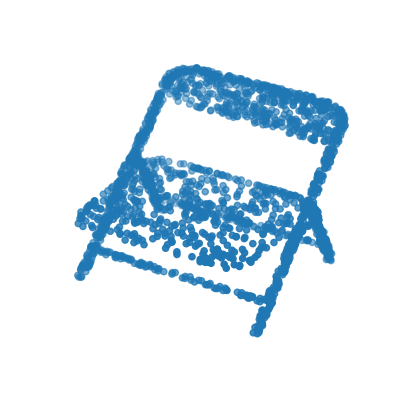

In [7]:
points = mesh.sample(2048)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
ax.set_axis_off()
plt.show()

To generate a `tf.data.Dataset()` we need to first parse through the ModelNet data
folders. Each mesh is loaded and sampled into a point cloud before being added to a
standard python list and converted to a `numpy` array. We also store the current
enumerate index value as the object label and use a dictionary to recall this later.

In [11]:
def parse_dataset(directory, num_points=2048):
    train_points = []
    train_labels = []
    test_points = []
    test_labels = []
    class_map = {}

    # MUDE AQUI TAMBÉM: use 'directory' em vez de 'DATA_DIR'
    folders = glob.glob(os.path.join(directory, "[!README]*"))

    for i, folder in enumerate(folders):
        folder_name = os.path.basename(folder)

        # 🛑 CORREÇÃO AQUI: Se for a pasta oculta do Mac, ignora e vai para a próxima
        if folder_name == "__MACOSX" or folder_name.startswith("."):
            continue

        print("processing class: {}".format(folder_name))

        # Usar os.path.basename é muito mais seguro do que .split("/")
        class_map[i] = folder_name

        # gather all files
        train_files = glob.glob(os.path.join(folder, "train/*"))
        test_files = glob.glob(os.path.join(folder, "test/*"))

        for f in train_files:
            train_points.append(trimesh.load(f).sample(num_points))
            train_labels.append(i)

        for f in test_files:
            test_points.append(trimesh.load(f).sample(num_points))
            test_labels.append(i)

    return (
        np.array(train_points),
        np.array(test_points),
        np.array(train_labels),
        np.array(test_labels),
        np.array(class_map), # Garante consistência de tipo ao converter
    )

Set the number of points to sample and batch size and parse the dataset. This can take
~5minutes to complete.

In [13]:
NUM_POINTS = 2048
NUM_CLASSES = 10
BATCH_SIZE = 32

# O seu cálculo inteligente do caminho correto:
path_para_ler = os.path.join(DATA_DIR, "ModelNet10") if os.path.exists(os.path.join(DATA_DIR, "ModelNet10")) else DATA_DIR

# CORREÇÃO AQUI: Passamos 'path_para_ler' como o primeiro argumento
train_points, test_points, train_labels, test_labels, CLASS_MAP = parse_dataset(
    path_para_ler,
    num_points=NUM_POINTS
)

processing class: desk
processing class: bathtub
processing class: table
processing class: bed
processing class: night_stand
processing class: dresser
processing class: chair
processing class: toilet
processing class: monitor
processing class: sofa


Our data can now be read into a `tf.data.Dataset()` object. We set the shuffle buffer
size to the entire size of the dataset as prior to this the data is ordered by class.
Data augmentation is important when working with point cloud data. We create a
augmentation function to jitter and shuffle the train dataset.

In [14]:
import tensorflow as tf

# 1. Definir a função de aumento de dados de forma compatível
def augment(points, label):
    # jitter points
    points += keras.random.uniform(points.shape, -0.005, 0.005, dtype="float64")
    # shuffle points
    points = keras.random.shuffle(points)
    return points, label

# 2. Segurança: Garantir que temos dados válidos antes de continuar
NUM_TRAIN_SAMPLES = len(train_points)
NUM_TEST_SAMPLES = len(test_points)

print(f"Quantidade de amostras de treino: {NUM_TRAIN_SAMPLES}")
print(f"Quantidade de amostras de teste: {NUM_TEST_SAMPLES}")

if NUM_TRAIN_SAMPLES == 0:
    raise ValueError("ERRO: 'train_points' está vazio. Certifique-se de ignorar a pasta '__MACOSX' na função 'parse_dataset'.")

# 3. Criar os datasets base
dataset = tf.data.Dataset.from_tensor_slices((train_points, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_points, test_labels))

# Definir tamanho da divisão de treino (80% treino, 20% validação)
train_size = int(NUM_TRAIN_SAMPLES * 0.8)

# 4. Preparar o pipeline de Treino (Embaralhar -> Dividir -> Aplicar Augment -> Batch)
# Usamos NUM_TRAIN_SAMPLES diretamente como o tamanho do buffer com segurança
train_dataset = (
    dataset.shuffle(buffer_size=NUM_TRAIN_SAMPLES)
    .take(train_size)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 5. Preparar o pipeline de Validação
validation_dataset = (
    dataset.skip(train_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 6. Preparar o pipeline de Teste
test_dataset = (
    test_dataset.shuffle(buffer_size=NUM_TEST_SAMPLES)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets criados e preparados com sucesso!")

Quantidade de amostras de treino: 3991
Quantidade de amostras de teste: 908
Datasets criados e preparados com sucesso!


### Build a model

Each convolution and fully-connected layer (with exception for end layers) consits of
Convolution / Dense -> Batch Normalization -> ReLU Activation.

In [15]:
def conv_bn(x, filters):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid")(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)


def dense_bn(x, filters):
    x = layers.Dense(filters)(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)

PointNet consists of two core components. The primary MLP network, and the transformer
net (T-net). The T-net aims to learn an affine transformation matrix by its own mini
network. The T-net is used twice. The first time to transform the input features (n, 3)
into a canonical representation. The second is an affine transformation for alignment in
feature space (n, 3). As per the original paper we constrain the transformation to be
close to an orthogonal matrix (i.e. ||X*X^T - I|| = 0).

In [16]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.eye = ops.eye(num_features)

    def __call__(self, x):
        x = ops.reshape(x, (-1, self.num_features, self.num_features))
        xxt = ops.tensordot(x, x, axes=(2, 2))
        xxt = ops.reshape(xxt, (-1, self.num_features, self.num_features))
        return ops.sum(self.l2reg * ops.square(xxt - self.eye))

 We can then define a general function to build T-net layers.

In [17]:
def tnet(inputs, num_features):
    # Initalise bias as the indentity matrix
    bias = keras.initializers.Constant(np.eye(num_features).flatten())
    reg = OrthogonalRegularizer(num_features)

    x = conv_bn(inputs, 32)
    x = conv_bn(x, 64)
    x = conv_bn(x, 512)
    x = layers.GlobalMaxPooling1D()(x)
    x = dense_bn(x, 256)
    x = dense_bn(x, 128)
    x = layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=bias,
        activity_regularizer=reg,
    )(x)
    feat_T = layers.Reshape((num_features, num_features))(x)
    # Apply affine transformation to input features
    return layers.Dot(axes=(2, 1))([inputs, feat_T])

The main network can be then implemented in the same manner where the t-net mini models
can be dropped in a layers in the graph. Here we replicate the network architecture
published in the original paper but with half the number of weights at each layer as we
are using the smaller 10 class ModelNet dataset.

In [18]:
inputs = keras.Input(shape=(NUM_POINTS, 3))

x = tnet(inputs, 3)
x = conv_bn(x, 32)
x = conv_bn(x, 32)
x = tnet(x, 32)
x = conv_bn(x, 32)
x = conv_bn(x, 64)
x = conv_bn(x, 512)
x = layers.GlobalMaxPooling1D()(x)
x = dense_bn(x, 256)
x = layers.Dropout(0.3)(x)
x = dense_bn(x, 128)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="pointnet")
model.summary()

Model: "pointnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2048, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2048, 32)  │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2048, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2048, 64)  │      2,112 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2048, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2048, 512) │     33,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048, 512) │      2,048 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2048, 512) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ activation_2[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9)         │      1,161 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 3, 3)      │          0 │ dense_2[0][0]   

 Total params: 748,979 (2.86 MB)

 Trainable params: 742,899 (2.83 MB)

 Non-trainable params: 6,080 (23.75 KB)

### Train model

Once the model is defined it can be trained like any other standard classification model
using `.compile()` and `.fit()`.

In [20]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), # Reduzido para maior estabilidade
    metrics=["sparse_categorical_accuracy"],
)

## Visualize predictions

We can use matplotlib to visualize our trained model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


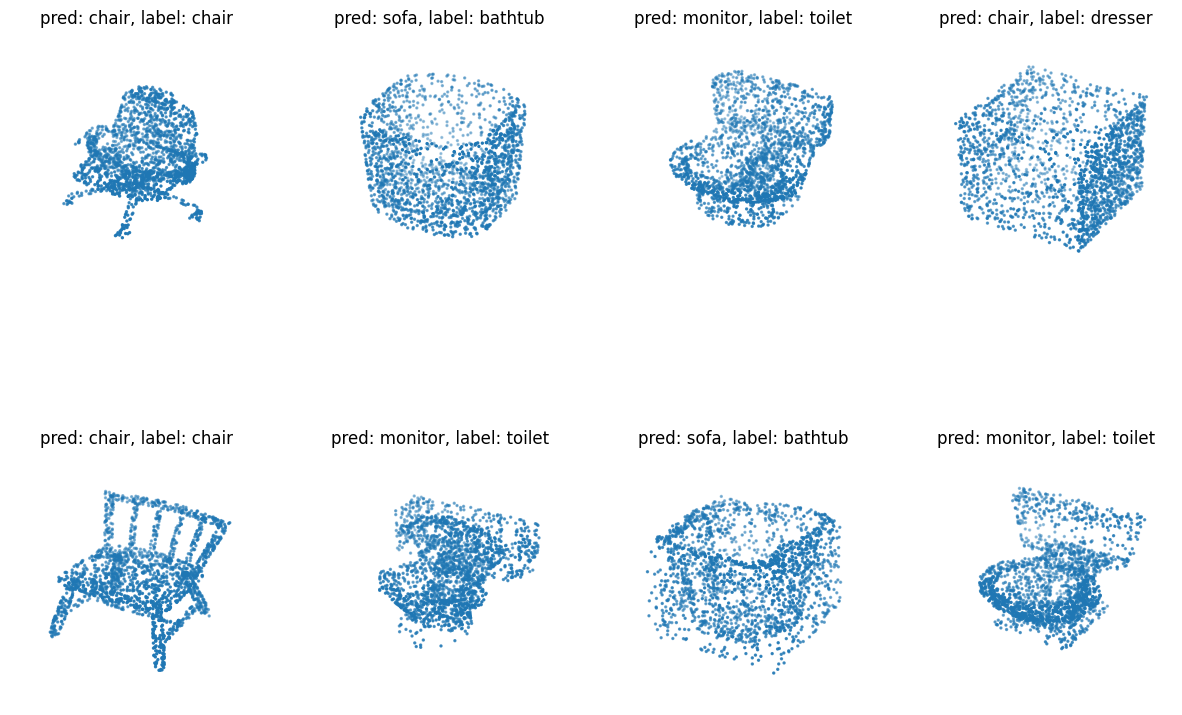

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = test_dataset.take(1)

points, labels = list(data)[0]
points = points[:8, ...]
labels = labels[:8, ...]

# run test data through model
preds = model.predict(points)
preds = ops.argmax(preds, -1)

# Converte para numpy de forma limpa
points = points.numpy()
preds_np = preds.numpy() if hasattr(preds, "numpy") else np.array(preds)
labels_np = labels.numpy() if hasattr(labels, "numpy") else np.array(labels)

# 🛑 CORREÇÃO IMPORTANTE: Desempacota o CLASS_MAP se ele tiver virado um array do NumPy
if isinstance(CLASS_MAP, np.ndarray):
    mapping = CLASS_MAP.item()
else:
    mapping = CLASS_MAP

# plot points with predicted class and label
fig = plt.figure(figsize=(15, 10))
for i in range(len(points)):
    ax = fig.add_subplot(2, 4, i + 1, projection="3d")
    ax.scatter(points[i, :, 0], points[i, :, 1], points[i, :, 2], s=2)

    # Extrai os IDs de classe purificados
    pred_idx = int(preds_np[i])
    label_idx = int(labels_np[i])

    # 🛑 Usa o 'mapping' desempacotado para resgatar os nomes textuais
    pred_class = mapping[pred_idx]
    label_class = mapping[label_idx]

    ax.set_title(f"pred: {pred_class}, label: {label_class}")
    ax.set_axis_off()

plt.show()